# Medallion Architecture <br> for a Messy Retail Sales Dataset
## Raw → Bronze → Silver → Gold

This revised notebook teaches the pipeline **one business rule at a time**.

## Business Rules
1. Missing `sale_id` → **cancelled transaction**
    
2. Missing `product` → **drop record**
    
3. Missing/empty `customer_name` → **drop record**
    
4. Null/missing/negative `discount` → **0.00**
    
5. Valid `sale_date` formats only:
   - `MM/DD/YYYY`
   - `YYYY-MM-DD`

6. Missing/malformed/invalid `sale_date` → **drop record**
    
7. Drop exact duplicate rows
    
8. `final_sale_price = (quantity * unit_price) - discount`

We will show for each rule:
- **why**
- **how**
- **SQL**
- **layer-to-layer transformation**
- **audit query / plot**


## Cell 01 — Import libraries and connect to DuckDB

### Why
We need a small local analytics engine for classroom use.

### What
Import libraries and open the DuckDB database.


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("medallion_messy_sales.duckdb")
print("Connected to DuckDB.")


Connected to DuckDB.


## Cell 02 — Define the source CSV file

### Why
A pipeline should be easy to rerun against a new batch.

### What
Set the CSV file name in one place.


In [2]:
csv_file = "sale_records_1400_messy.csv"
print("Source file:", csv_file)


Source file: sale_records_1400_messy.csv


## Cell 03 — Preview the raw file

### Why
Students should see the messy source before transformations.

### What
Read the file as strings and inspect sample rows.


In [3]:
raw_preview = pd.read_csv(csv_file, dtype=str)
raw_preview.head(12)


,sale_id,sale_type,product,customer_name,customer_email,customer_country,quantity,unit_price,discount,store_location,sale_date
0,1,ON-LINE,IPAD,Megan Carter,megan.carter83@outlook.com,USA,1,700,0.00,USA,06/21/2025
1,2,ON-LINE,IPAD,Kevin Johnson,kevin.johnson34@yahoo.com,USA,1,700,0.00,USA,11/08/2025
2,3,ON-LINE,COMPUTER,Rebecca White,rebecca.white18@proton.me,USA,1,1400,0.00,USA,11/23/2025
3,4,IN-STORE,WATCH,Jack Gonzalez,jack.gonzalez6@yahoo.com,GERMANY,2,250,60.00,USA,11/13/2025
4,5,ON-LINE,IPHONE,Ryan Jackson,ryan.jackson94@proton.me,CANADA,3,1100,396.00,CANADA,08/01/2025
5,6,IN-STORE,COMPUTER,Megan Wilson,megan.wilson17@outlook.com,CANADA,3,1400,210.00,ENGLAND,10/24/2025
6,7,IN-STORE,IPHONE,Jason Perez,jason.perez28@outlook.com,USA,1,1100,88.00,USA,01/11/2025
7,8,ON-LINE,IPAD,Jeffrey Parker,jeffrey.parker39@proton.me,MEXICO,2,700,0.00,ENGLAND,12/18/2025
8,9,ON-LINE,WATCH,George Stewart,george.stewart40@yahoo.com,ENGLAND,1,250,0.00,CANADA,04/15/2025
9,10,IN-STORE,COMPUTER,Bruce Taylor,bruce.taylor94@icloud.com,FRANCE,1,1400,112.00,USA,12/09/2025


## Cell 04 — Create schemas

### Why
Schemas separate the warehouse layers clearly.

### What
Create `raw`, `bronze`, `silver`, and `gold`.


In [4]:
con.execute("CREATE SCHEMA IF NOT EXISTS raw;")
con.execute("CREATE SCHEMA IF NOT EXISTS bronze;")
con.execute("CREATE SCHEMA IF NOT EXISTS silver;")
con.execute("CREATE SCHEMA IF NOT EXISTS gold;")

con.execute("""
SELECT schema_name
FROM information_schema.schemata
ORDER BY schema_name;
""").df()


,schema_name
0,bronze
1,gold
2,information_schema
3,main
4,main
5,main
6,pg_catalog
7,raw
8,silver


# Raw and Bronze

Bronze preserves the landed source before business cleanup.


## Cell 05 — Load the CSV into `raw.sales_file`

### Why
We want a warehouse copy of the exact input.

### What
Load the CSV as text using `all_varchar=true`.


In [5]:
con.execute(f"""
CREATE OR REPLACE TABLE raw.sales_file AS
SELECT
    ROW_NUMBER() OVER () AS raw_row_num,
    *
FROM read_csv_auto('{csv_file}', header=true, all_varchar=true);
""")
con.execute("SELECT COUNT(*) AS raw_rows FROM raw.sales_file").df()


,raw_rows
0,1400


## Cell 06 — Create `bronze.sales_raw`

### Why
Bronze is the warehouse landing layer.

### What
Copy raw data into Bronze.


In [6]:
con.execute("""
CREATE OR REPLACE TABLE bronze.sales_raw AS
SELECT *
FROM raw.sales_file;
""")
con.execute("SELECT COUNT(*) AS bronze_rows FROM bronze.sales_raw").df()


,bronze_rows
0,1400


## Cell 07 — Bronze profiling

### Why
Measure the mess before cleanup.

### What
Count missing IDs, missing products, missing names, missing dates, and duplicates.


In [7]:
con.execute("""
SELECT 'total_rows' AS metric, COUNT(*) AS value
FROM bronze.sales_raw

UNION ALL

SELECT 'missing_sale_id_rows',
       SUM(CASE WHEN NULLIF(TRIM(sale_id), '') IS NULL THEN 1 ELSE 0 END)
FROM bronze.sales_raw

UNION ALL

SELECT 'missing_product_rows',
       SUM(CASE WHEN NULLIF(TRIM(product), '') IS NULL THEN 1 ELSE 0 END)
FROM bronze.sales_raw

UNION ALL

SELECT 'missing_customer_name_rows',
       SUM(CASE WHEN NULLIF(TRIM(customer_name), '') IS NULL THEN 1 ELSE 0 END)
FROM bronze.sales_raw

UNION ALL

SELECT 'missing_sale_date_rows',
       SUM(CASE WHEN NULLIF(TRIM(sale_date), '') IS NULL THEN 1 ELSE 0 END)
FROM bronze.sales_raw

UNION ALL

SELECT 'extra_duplicate_rows',
       COALESCE((
           SELECT SUM(cnt - 1)
           FROM (
               SELECT
                   sale_id, sale_type, product, customer_name, customer_email,
                   customer_country, quantity, unit_price, discount, store_location, sale_date,
                   COUNT(*) AS cnt
               FROM bronze.sales_raw
               GROUP BY
                   sale_id, sale_type, product, customer_name, customer_email,
                   customer_country, quantity, unit_price, discount, store_location, sale_date
               HAVING COUNT(*) > 1
           )
       ), 0);
""").df()


,metric,value
0,total_rows,1400.0
1,missing_sale_id_rows,33.0
2,missing_product_rows,30.0
3,missing_customer_name_rows,21.0
4,missing_sale_date_rows,6.0
5,extra_duplicate_rows,31.0


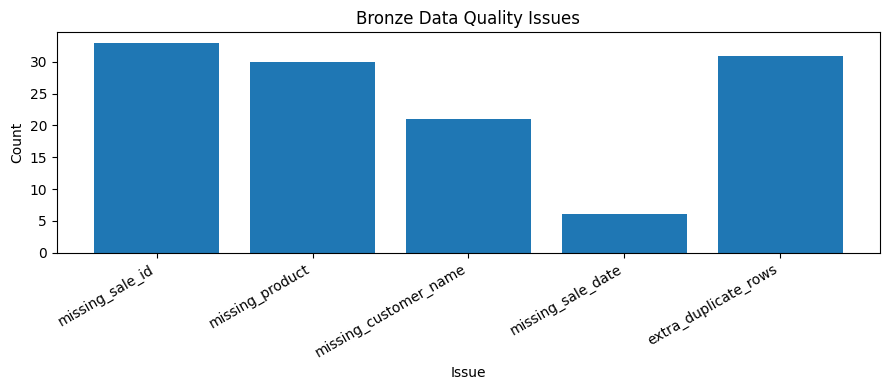

In [8]:
df_bronze = con.execute("""
WITH dups AS (
    SELECT
        sale_id, sale_type, product, customer_name, customer_email,
        customer_country, quantity, unit_price, discount, store_location, sale_date,
        COUNT(*) AS cnt
    FROM bronze.sales_raw
    GROUP BY
        sale_id, sale_type, product, customer_name, customer_email,
        customer_country, quantity, unit_price, discount, store_location, sale_date
    HAVING COUNT(*) > 1
)
SELECT 'missing_sale_id' AS issue, SUM(CASE WHEN NULLIF(TRIM(sale_id), '') IS NULL THEN 1 ELSE 0 END) AS issue_count FROM bronze.sales_raw
UNION ALL
SELECT 'missing_product', SUM(CASE WHEN NULLIF(TRIM(product), '') IS NULL THEN 1 ELSE 0 END) FROM bronze.sales_raw
UNION ALL
SELECT 'missing_customer_name', SUM(CASE WHEN NULLIF(TRIM(customer_name), '') IS NULL THEN 1 ELSE 0 END) FROM bronze.sales_raw
UNION ALL
SELECT 'missing_sale_date', SUM(CASE WHEN NULLIF(TRIM(sale_date), '') IS NULL THEN 1 ELSE 0 END) FROM bronze.sales_raw
UNION ALL
SELECT 'extra_duplicate_rows', COALESCE((SELECT SUM(cnt - 1) FROM dups), 0);
""").df()

plt.figure(figsize=(9,4))
plt.bar(df_bronze["issue"], df_bronze["issue_count"])
plt.title("Bronze Data Quality Issues")
plt.xlabel("Issue")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


# Silver Layer: Business Rules One-by-One

## Cell 08 — Rule 7: Deduplicate exact duplicate rows

### Why
Duplicates inflate counts and revenue.

### How
Use `SELECT DISTINCT` across all source columns.

### Transformation
`bronze.sales_raw` → `silver.step01_dedup`


In [9]:
con.execute("""
CREATE OR REPLACE TABLE silver.step01_dedup AS
SELECT DISTINCT
    sale_id, sale_type, product, customer_name, customer_email,
    customer_country, quantity, unit_price, discount, store_location, sale_date
FROM bronze.sales_raw;
""")
con.execute("""
SELECT
    (SELECT COUNT(*) FROM bronze.sales_raw) AS bronze_rows,
    (SELECT COUNT(*) FROM silver.step01_dedup) AS dedup_rows,
    (SELECT COUNT(*) FROM bronze.sales_raw) - (SELECT COUNT(*) FROM silver.step01_dedup) AS duplicates_removed;
""").df()


,bronze_rows,dedup_rows,duplicates_removed
0,1400,1369,31


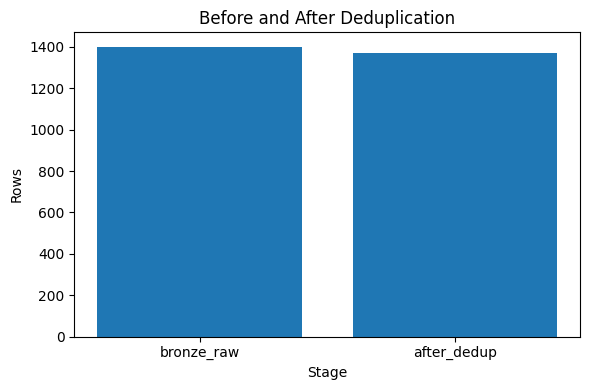

In [10]:
df = con.execute("""
SELECT 'bronze_raw' AS stage, COUNT(*) AS row_count FROM bronze.sales_raw
UNION ALL
SELECT 'after_dedup', COUNT(*) FROM silver.step01_dedup;
""").df()

plt.figure(figsize=(6,4))
plt.bar(df["stage"], df["row_count"])
plt.title("Before and After Deduplication")
plt.xlabel("Stage")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


## Cell 09 — Standardize strings and safe casts

### Why
We want consistent text and safe numeric parsing before enforcing more rules.

### Transformation
`silver.step01_dedup` → `silver.step02_standardized`


In [11]:
con.execute("""
CREATE OR REPLACE TABLE silver.step02_standardized AS
SELECT
    NULLIF(TRIM(sale_id), '') AS sale_id_raw,
    UPPER(NULLIF(TRIM(sale_type), '')) AS sale_type,
    UPPER(NULLIF(TRIM(product), '')) AS product,
    NULLIF(TRIM(customer_name), '') AS customer_name,
    LOWER(NULLIF(TRIM(customer_email), '')) AS customer_email,
    UPPER(NULLIF(TRIM(customer_country), '')) AS customer_country,
    TRY_CAST(NULLIF(TRIM(quantity), '') AS INTEGER) AS quantity,
    TRY_CAST(NULLIF(TRIM(unit_price), '') AS DOUBLE) AS unit_price,
    NULLIF(TRIM(discount), '') AS discount_raw,
    UPPER(NULLIF(TRIM(store_location), '')) AS store_location,
    NULLIF(TRIM(sale_date), '') AS sale_date_raw
FROM silver.step01_dedup;
""")
con.execute("SELECT * FROM silver.step02_standardized LIMIT 10").df()


,sale_id_raw,sale_type,product,customer_name,customer_email,customer_country,quantity,unit_price,discount_raw,store_location,sale_date_raw
0,27,IN-STORE,COMPUTER,Kenneth Thomas,kenneth.thomas17@outlook.com,USA,2,1400.0,224.00,USA,11/25/2025
1,39,IN-STORE,TV,George Ramirez,george.ramirez86@outlook.com,USA,1,900.0,0.00,USA,04/02/2025
2,41,IN-STORE,WATCH,Betty Rivera,betty.rivera70@icloud.com,ITALY,3,250.0,22.50,USA,10/29/2025
3,59,IN-STORE,COMPUTER,William Hill,william.hill31@icloud.com,USA,2,1400.0,224.00,USA,12/01/2025
4,81,ON-LINE,IPHONE,Thomas Green,thomas.green21@icloud.com,ENGLAND,2,1100.0,264.00,CANADA,03/02/2025
5,91,IN-STORE,COMPUTER,Lisa Moore,lisa.moore10@icloud.com,CANADA,1,1400.0,0.00,CANADA,10/24/2025
6,105,ON-LINE,TV,Kevin Johnson,kevin.johnson34@yahoo.com,USA,1,900.0,135.00,USA,04/21/2025
7,114,IN-STORE,TV,Rebecca White,rebecca.white18@proton.me,USA,1,900.0,27.00,USA,12/24/2025
8,120,ON-LINE,COMPUTER,Kevin Johnson,kevin.johnson34@yahoo.com,USA,4,1400.0,280.00,USA,10/13/2025
9,121,ON-LINE,IPAD,Ryan Jackson,ryan.jackson94@proton.me,CANADA,1,700.0,35.00,ENGLAND,11/11/2025


## Cell 10 — Rule 4: Fix discount values

### Why
Missing or negative discount should be treated as no discount.

### How
Create a cleaned numeric `discount`.

### Transformation
`silver.step02_standardized` → `silver.step03_discount_fixed`


In [12]:
con.execute("""
CREATE OR REPLACE TABLE silver.step03_discount_fixed AS
SELECT
    *,
    CASE
        WHEN TRY_CAST(discount_raw AS DOUBLE) IS NULL THEN 0.00
        WHEN TRY_CAST(discount_raw AS DOUBLE) < 0 THEN 0.00
        ELSE TRY_CAST(discount_raw AS DOUBLE)
    END AS discount
FROM silver.step02_standardized;
""")
con.execute("""
SELECT
    SUM(CASE WHEN discount_raw IS NULL THEN 1 ELSE 0 END) AS missing_discount_rows,
    SUM(CASE WHEN TRY_CAST(discount_raw AS DOUBLE) < 0 THEN 1 ELSE 0 END) AS negative_discount_rows,
    SUM(CASE WHEN discount = 0.00 THEN 1 ELSE 0 END) AS final_zero_discount_rows
FROM silver.step03_discount_fixed;
""").df()


,missing_discount_rows,negative_discount_rows,final_zero_discount_rows
0,8.0,6.0,378.0


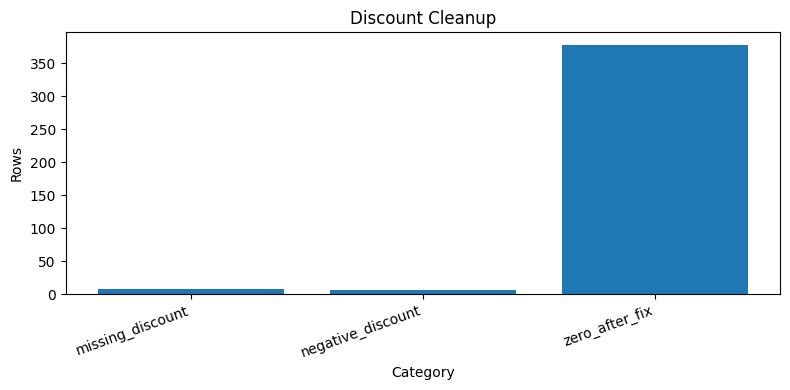

In [13]:
df = con.execute("""
SELECT 'missing_discount' AS category, SUM(CASE WHEN discount_raw IS NULL THEN 1 ELSE 0 END) AS row_count
FROM silver.step03_discount_fixed
UNION ALL
SELECT 'negative_discount', SUM(CASE WHEN TRY_CAST(discount_raw AS DOUBLE) < 0 THEN 1 ELSE 0 END)
FROM silver.step03_discount_fixed
UNION ALL
SELECT 'zero_after_fix', SUM(CASE WHEN discount = 0.00 THEN 1 ELSE 0 END)
FROM silver.step03_discount_fixed;
""").df()

plt.figure(figsize=(8,4))
plt.bar(df["category"], df["row_count"])
plt.title("Discount Cleanup")
plt.xlabel("Category")
plt.ylabel("Rows")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## Cell 11 — Rules 5 and 6: Parse allowed date formats

### Why
Only two sale date formats are valid:
- `MM/DD/YYYY`
- `YYYY-MM-DD`

Missing or invalid dates must be dropped later.

### How
Use `TRY_STRPTIME` for both formats and `COALESCE`.

### Transformation
`silver.step03_discount_fixed` → `silver.step04_date_parsed`


In [14]:
con.execute("""
CREATE OR REPLACE TABLE silver.step04_date_parsed AS
SELECT
    *,
    COALESCE(
        TRY_STRPTIME(sale_date_raw, '%m/%d/%Y')::DATE,
        TRY_STRPTIME(sale_date_raw, '%Y-%m-%d')::DATE
    ) AS sale_date
FROM silver.step03_discount_fixed;
""")
con.execute("""
SELECT
    COUNT(*) AS rows_checked,
    SUM(CASE WHEN sale_date IS NULL THEN 1 ELSE 0 END) AS invalid_or_missing_sale_date_rows
FROM silver.step04_date_parsed;
""").df()


,rows_checked,invalid_or_missing_sale_date_rows
0,1369,27.0


In [15]:
con.execute("""
SELECT sale_date_raw, COUNT(*) AS row_count
FROM silver.step04_date_parsed
WHERE sale_date IS NULL
GROUP BY sale_date_raw
ORDER BY row_count DESC, sale_date_raw
LIMIT 20;
""").df()


,sale_date_raw,row_count
0,None,6
1,date,2
2,datedate,2
3,invalid_date,2
4,0045,1
5,005/2025,1
6,02/10-2025,1
7,08/34/29/2025,1
8,09/03-2025,1
9,1-20/2025,1


## Cell 12 — Rules 2, 3, and 6: Build rejected records

### Why
These rows are not valid for warehousing:
- missing product
- missing customer name
- invalid/missing sale date

### Important
Rejected rows are **not** cancelled.

### Transformation
`silver.step04_date_parsed` → `silver.rejected_records`


In [16]:
con.execute("""
CREATE OR REPLACE TABLE silver.rejected_records AS
SELECT
    *,
    CASE
        WHEN product IS NULL THEN 'REJECT_MISSING_PRODUCT'
        WHEN customer_name IS NULL THEN 'REJECT_MISSING_CUSTOMER_NAME'
        WHEN sale_date IS NULL THEN 'REJECT_INVALID_OR_MISSING_SALE_DATE'
        ELSE 'REJECT_OTHER'
    END AS reject_reason
FROM silver.step04_date_parsed
WHERE product IS NULL OR customer_name IS NULL OR sale_date IS NULL;
""")
con.execute("""
SELECT reject_reason, COUNT(*) AS row_count
FROM silver.rejected_records
GROUP BY reject_reason
ORDER BY row_count DESC;
""").df()


,reject_reason,row_count
0,REJECT_MISSING_PRODUCT,30
1,REJECT_INVALID_OR_MISSING_SALE_DATE,27
2,REJECT_MISSING_CUSTOMER_NAME,21


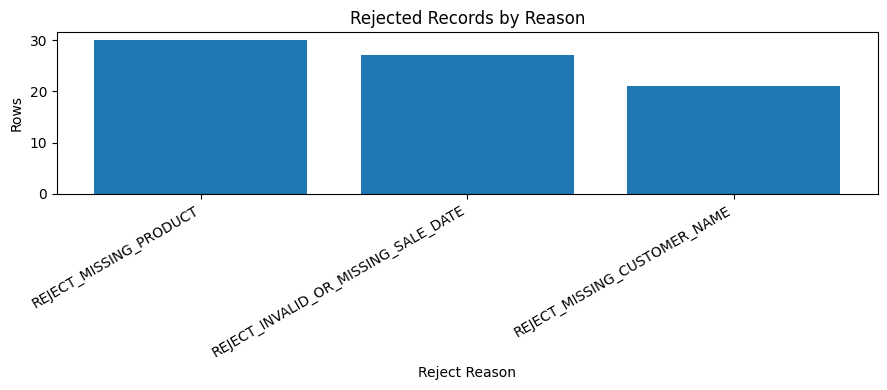

In [17]:
df = con.execute("""
SELECT reject_reason, COUNT(*) AS row_count
FROM silver.rejected_records
GROUP BY reject_reason
ORDER BY row_count DESC;
""").df()

plt.figure(figsize=(9,4))
plt.bar(df["reject_reason"], df["row_count"])
plt.title("Rejected Records by Reason")
plt.xlabel("Reject Reason")
plt.ylabel("Rows")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Cell 13 — Rule 1: Build cancelled transactions

### Why
Business wants to know how many transactions were cancelled and for which products.

### Important
A row counts as cancelled only if it is otherwise valid.
Rejected rows do not become cancelled rows.

### Transformation
`silver.step04_date_parsed` → `silver.cancelled_transactions`


In [18]:
con.execute("""
CREATE OR REPLACE TABLE silver.cancelled_transactions AS
SELECT
    sale_type, product, customer_name, customer_email, customer_country,
    quantity, unit_price, discount, store_location, sale_date
FROM silver.step04_date_parsed
WHERE sale_id_raw IS NULL
  AND product IS NOT NULL
  AND customer_name IS NOT NULL
  AND sale_date IS NOT NULL;
""")
con.execute("SELECT COUNT(*) AS cancelled_transaction_rows FROM silver.cancelled_transactions").df()


,cancelled_transaction_rows
0,33


In [19]:
con.execute("""
SELECT product, COUNT(*) AS cancelled_count
FROM silver.cancelled_transactions
GROUP BY product
ORDER BY cancelled_count DESC;
""").df()


,product,cancelled_count
0,IPHONE,11
1,COMPUTER,8
2,IPAD,5
3,WATCH,4
4,EBIKE,3
5,TV,2


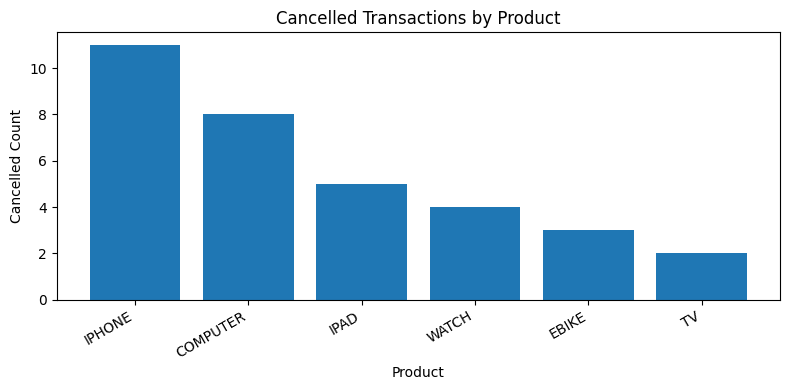

In [20]:
df = con.execute("""
SELECT product, COUNT(*) AS cancelled_count
FROM silver.cancelled_transactions
GROUP BY product
ORDER BY cancelled_count DESC;
""").df()

plt.figure(figsize=(8,4))
plt.bar(df["product"], df["cancelled_count"])
plt.title("Cancelled Transactions by Product")
plt.xlabel("Product")
plt.ylabel("Cancelled Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Cell 14 — Build valid non-cancelled rows

### Why
Gold should use only trusted, valid, non-cancelled rows.

### Transformation
`silver.step04_date_parsed` → `silver.step05_valid_non_cancelled`


In [21]:
con.execute("""
CREATE OR REPLACE TABLE silver.step05_valid_non_cancelled AS
SELECT *
FROM silver.step04_date_parsed
WHERE sale_id_raw IS NOT NULL
  AND product IS NOT NULL
  AND customer_name IS NOT NULL
  AND sale_date IS NOT NULL;
""")
con.execute("SELECT COUNT(*) AS valid_non_cancelled_rows FROM silver.step05_valid_non_cancelled").df()


,valid_non_cancelled_rows
0,1258


## Cell 15 — Rule 8: Compute final sale price

### Why
This is the trusted monetary measure used in analytics.

### Transformation
`silver.step05_valid_non_cancelled` → `silver.sales_clean`


In [22]:
con.execute("""
CREATE OR REPLACE TABLE silver.sales_clean AS
SELECT
    sale_id_raw AS sale_id,
    sale_type,
    product,
    customer_name,
    customer_email,
    customer_country,
    quantity,
    unit_price,
    discount,
    store_location,
    sale_date,
    (quantity * unit_price) - discount AS final_sale_price
FROM silver.step05_valid_non_cancelled;
""")
con.execute("SELECT * FROM silver.sales_clean LIMIT 10").df()


,sale_id,sale_type,product,customer_name,customer_email,customer_country,quantity,unit_price,discount,store_location,sale_date,final_sale_price
0,27,IN-STORE,COMPUTER,Kenneth Thomas,kenneth.thomas17@outlook.com,USA,2,1400.0,224.0,USA,2025-11-25,2576.0
1,39,IN-STORE,TV,George Ramirez,george.ramirez86@outlook.com,USA,1,900.0,0.0,USA,2025-04-02,900.0
2,41,IN-STORE,WATCH,Betty Rivera,betty.rivera70@icloud.com,ITALY,3,250.0,22.5,USA,2025-10-29,727.5
3,59,IN-STORE,COMPUTER,William Hill,william.hill31@icloud.com,USA,2,1400.0,224.0,USA,2025-12-01,2576.0
4,81,ON-LINE,IPHONE,Thomas Green,thomas.green21@icloud.com,ENGLAND,2,1100.0,264.0,CANADA,2025-03-02,1936.0
5,91,IN-STORE,COMPUTER,Lisa Moore,lisa.moore10@icloud.com,CANADA,1,1400.0,0.0,CANADA,2025-10-24,1400.0
6,105,ON-LINE,TV,Kevin Johnson,kevin.johnson34@yahoo.com,USA,1,900.0,135.0,USA,2025-04-21,765.0
7,114,IN-STORE,TV,Rebecca White,rebecca.white18@proton.me,USA,1,900.0,27.0,USA,2025-12-24,873.0
8,120,ON-LINE,COMPUTER,Kevin Johnson,kevin.johnson34@yahoo.com,USA,4,1400.0,280.0,USA,2025-10-13,5320.0
9,121,ON-LINE,IPAD,Ryan Jackson,ryan.jackson94@proton.me,CANADA,1,700.0,35.0,ENGLAND,2025-11-11,665.0


## Cell 16 — Audit all outcomes together

### Why
Students need one summary of the full pipeline.


In [23]:
con.execute("""
SELECT 'bronze_raw_rows' AS category, COUNT(*) AS row_count FROM bronze.sales_raw
UNION ALL
SELECT 'after_dedup', COUNT(*) FROM silver.step01_dedup
UNION ALL
SELECT 'rejected_rows', COUNT(*) FROM silver.rejected_records
UNION ALL
SELECT 'cancelled_rows', COUNT(*) FROM silver.cancelled_transactions
UNION ALL
SELECT 'trusted_sales_clean', COUNT(*) FROM silver.sales_clean
ORDER BY category;
""").df()


,category,row_count
0,after_dedup,1369
1,bronze_raw_rows,1400
2,cancelled_rows,33
3,rejected_rows,78
4,trusted_sales_clean,1258


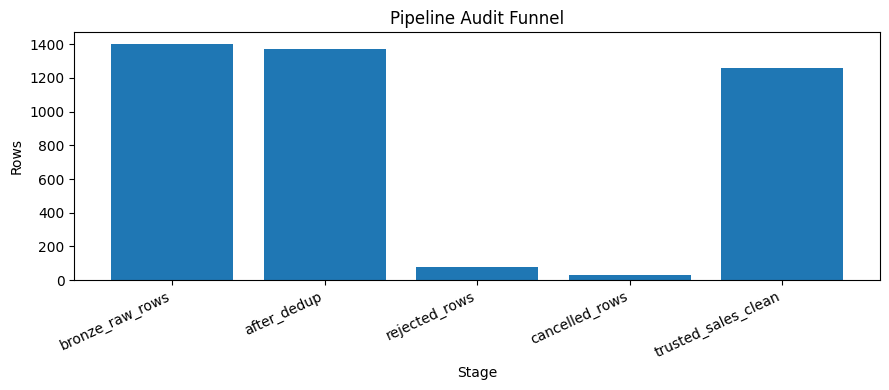

In [24]:
df = con.execute("""
SELECT 'bronze_raw_rows' AS category, COUNT(*) AS row_count FROM bronze.sales_raw
UNION ALL
SELECT 'after_dedup', COUNT(*) FROM silver.step01_dedup
UNION ALL
SELECT 'rejected_rows', COUNT(*) FROM silver.rejected_records
UNION ALL
SELECT 'cancelled_rows', COUNT(*) FROM silver.cancelled_transactions
UNION ALL
SELECT 'trusted_sales_clean', COUNT(*) FROM silver.sales_clean;
""").df()

plt.figure(figsize=(9,4))
plt.bar(df["category"], df["row_count"])
plt.title("Pipeline Audit Funnel")
plt.xlabel("Stage")
plt.ylabel("Rows")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


# Gold Layer

Gold organizes trusted Silver data into a star schema for OLAP.


## Cell 17 — Create Gold dimensions and fact table

### Why
The Gold layer is optimized for analytics and reporting.


In [25]:
con.execute("""
CREATE OR REPLACE TABLE gold.dim_customer AS
SELECT
    ROW_NUMBER() OVER (ORDER BY customer_email) AS customer_key,
    customer_name,
    customer_email,
    customer_country
FROM (
    SELECT DISTINCT customer_name, customer_email, customer_country
    FROM silver.sales_clean
);
""")

con.execute("""
CREATE OR REPLACE TABLE gold.dim_product AS
SELECT
    ROW_NUMBER() OVER (ORDER BY product) AS product_key,
    product
FROM (
    SELECT DISTINCT product
    FROM silver.sales_clean
);
""")

con.execute("""
CREATE OR REPLACE TABLE gold.dim_store AS
SELECT
    ROW_NUMBER() OVER (ORDER BY store_location) AS store_key,
    store_location
FROM (
    SELECT DISTINCT store_location
    FROM silver.sales_clean
);
""")

con.execute("""
CREATE OR REPLACE TABLE gold.dim_date AS
SELECT
    ROW_NUMBER() OVER (ORDER BY sale_date) AS date_key,
    sale_date AS full_date,
    EXTRACT(YEAR FROM sale_date) AS year_num,
    EXTRACT(QUARTER FROM sale_date) AS quarter_num,
    EXTRACT(MONTH FROM sale_date) AS month_num,
    STRFTIME(sale_date, '%B') AS month_name,
    EXTRACT(DAY FROM sale_date) AS day_num,
    STRFTIME(sale_date, '%A') AS day_name,
    STRFTIME(sale_date, '%Y-%m') AS year_month
FROM (
    SELECT DISTINCT sale_date
    FROM silver.sales_clean
);
""")

con.execute("""
CREATE OR REPLACE TABLE gold.fact_sales AS
SELECT
    s.sale_id,
    dc.customer_key,
    dp.product_key,
    ds.store_key,
    dd.date_key,
    s.sale_type,
    s.quantity,
    s.unit_price,
    s.discount,
    s.final_sale_price
FROM silver.sales_clean s
JOIN gold.dim_customer dc ON s.customer_email = dc.customer_email
JOIN gold.dim_product dp ON s.product = dp.product
JOIN gold.dim_store ds ON s.store_location = ds.store_location
JOIN gold.dim_date dd ON s.sale_date = dd.full_date;
""")

con.execute("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'gold'
ORDER BY table_name;
""").df()


,table_name
0,dim_customer
1,dim_date
2,dim_product
3,dim_store
4,fact_sales


## Cell 18 — OLAP 1: Total final sales by product

### Why
This query demonstrates a common OLAP-style business insight on the Gold layer.


In [26]:
con.execute("""
SELECT p.product, ROUND(SUM(f.final_sale_price), 2) AS total_final_sales
FROM gold.fact_sales f
JOIN gold.dim_product p ON f.product_key = p.product_key
GROUP BY p.product
ORDER BY total_final_sales DESC;
""").df()

,product,total_final_sales
0,IPHONE,562276.0
1,COMPUTER,544208.0
2,EBIKE,345796.0
3,TV,266877.0
4,IPAD,173950.0
5,WATCH,92142.5


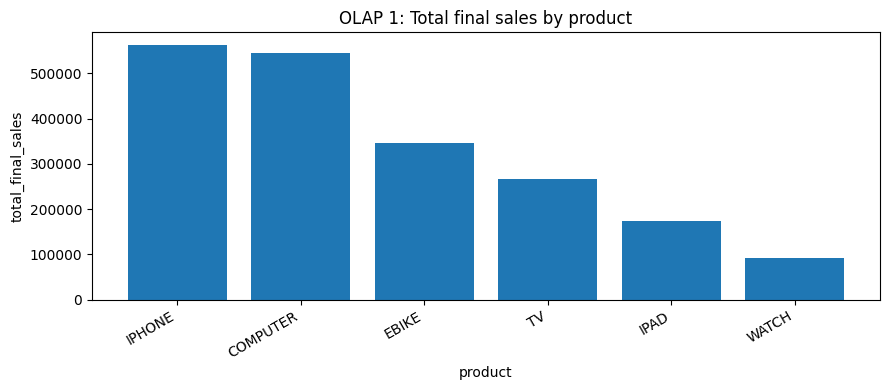

In [27]:
df = con.execute("""
SELECT p.product, ROUND(SUM(f.final_sale_price), 2) AS total_final_sales
FROM gold.fact_sales f
JOIN gold.dim_product p ON f.product_key = p.product_key
GROUP BY p.product
ORDER BY total_final_sales DESC;
""").df()

plt.figure(figsize=(9,4))
plt.bar(df["product"], df["total_final_sales"])
plt.title("OLAP 1: Total final sales by product")
plt.xlabel("product")
plt.ylabel("total_final_sales")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Cell 20 — OLAP 2: Monthly sales trend

### Why
This query demonstrates a common OLAP-style business insight on the Gold layer.


In [28]:
con.execute("""
SELECT d.year_month, ROUND(SUM(f.final_sale_price), 2) AS total_final_sales
FROM gold.fact_sales f
JOIN gold.dim_date d ON f.date_key = d.date_key
GROUP BY d.year_month
ORDER BY d.year_month;
""").df()

,year_month,total_final_sales
0,2025-01,68366.0
1,2025-02,85736.0
2,2025-03,104764.0
3,2025-04,112029.5
4,2025-05,101467.5
5,2025-06,118221.5
6,2025-07,137363.5
7,2025-08,136972.0
8,2025-09,175791.5
9,2025-10,189975.5


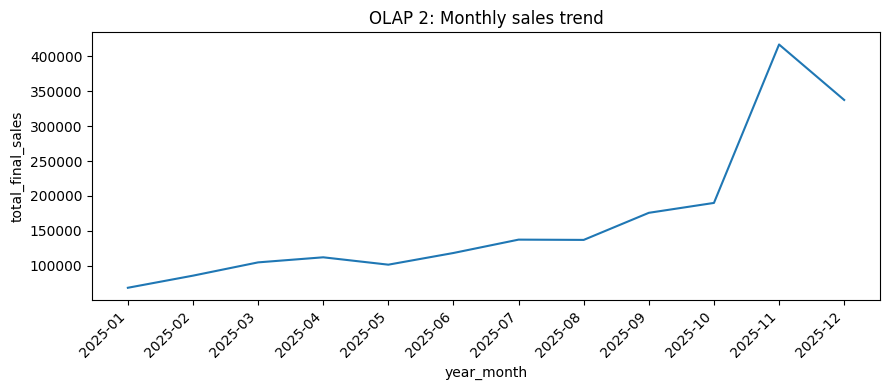

In [29]:
df = con.execute("""
SELECT d.year_month, ROUND(SUM(f.final_sale_price), 2) AS total_final_sales
FROM gold.fact_sales f
JOIN gold.dim_date d ON f.date_key = d.date_key
GROUP BY d.year_month
ORDER BY d.year_month;
""").df()

plt.figure(figsize=(9,4))
plt.plot(df["year_month"], df["total_final_sales"])
plt.title("OLAP 2: Monthly sales trend")
plt.xlabel("year_month")
plt.ylabel("total_final_sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Cell 22 — OLAP 3: Sales by customer country

### Why
This query demonstrates a common OLAP-style business insight on the Gold layer.


In [30]:
con.execute("""
SELECT c.customer_country, ROUND(SUM(f.final_sale_price), 2) AS total_final_sales
FROM gold.fact_sales f
JOIN gold.dim_customer c ON f.customer_key = c.customer_key
GROUP BY c.customer_country
ORDER BY total_final_sales DESC;
""").df()

,customer_country,total_final_sales
0,USA,1106054.5
1,CANADA,214180.5
2,GERMANY,173580.0
3,FRANCE,156217.5
4,ENGLAND,103277.5
5,MEXICO,95749.5
6,ITALY,87216.5
7,CHINA,48973.5


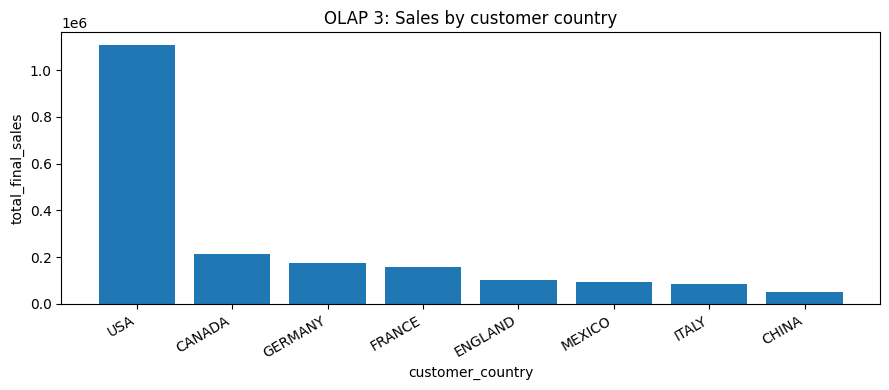

In [31]:
df = con.execute("""
SELECT c.customer_country, ROUND(SUM(f.final_sale_price), 2) AS total_final_sales
FROM gold.fact_sales f
JOIN gold.dim_customer c ON f.customer_key = c.customer_key
GROUP BY c.customer_country
ORDER BY total_final_sales DESC;
""").df()

plt.figure(figsize=(9,4))
plt.bar(df["customer_country"], df["total_final_sales"])
plt.title("OLAP 3: Sales by customer country")
plt.xlabel("customer_country")
plt.ylabel("total_final_sales")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Cell 24 — OLAP 4: Sales by store location

### Why
This query demonstrates a common OLAP-style business insight on the Gold layer.


In [32]:
con.execute("""
SELECT s.store_location, ROUND(SUM(f.final_sale_price), 2) AS total_final_sales, COUNT(*) AS transactions
FROM gold.fact_sales f
JOIN gold.dim_store s ON f.store_key = s.store_key
GROUP BY s.store_location
ORDER BY total_final_sales DESC;
""").df()

,store_location,total_final_sales,transactions
0,USA,1056654.5,686
1,CANADA,559932.5,337
2,ENGLAND,368662.5,235


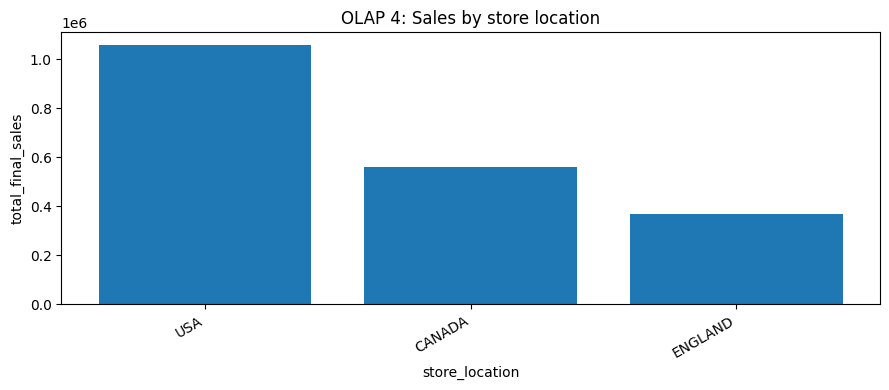

In [33]:
df = con.execute("""
SELECT s.store_location, ROUND(SUM(f.final_sale_price), 2) AS total_final_sales, COUNT(*) AS transactions
FROM gold.fact_sales f
JOIN gold.dim_store s ON f.store_key = s.store_key
GROUP BY s.store_location
ORDER BY total_final_sales DESC;
""").df()

plt.figure(figsize=(9,4))
plt.bar(df["store_location"], df["total_final_sales"])
plt.title("OLAP 4: Sales by store location")
plt.xlabel("store_location")
plt.ylabel("total_final_sales")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

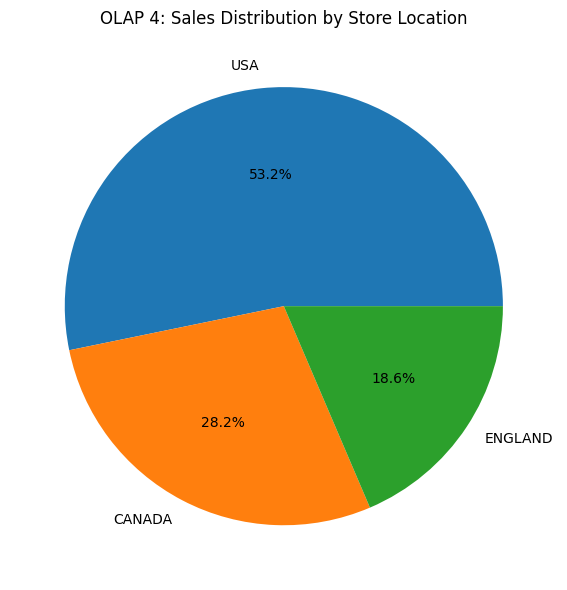

In [34]:
# sales by store location as a Pie Chart
df = con.execute("""
SELECT 
    s.store_location, 
    ROUND(SUM(f.final_sale_price), 2) AS total_final_sales, 
    COUNT(*) AS transactions
FROM gold.fact_sales f
JOIN gold.dim_store s 
  ON f.store_key = s.store_key
GROUP BY s.store_location
ORDER BY total_final_sales DESC;
""").df()

plt.figure(figsize=(6, 6))

plt.pie(
    df["total_final_sales"],
    labels=df["store_location"],
    autopct='%1.1f%%'
)

plt.title("OLAP 4: Sales Distribution by Store Location")

plt.tight_layout()
plt.show()

## Cell 26 — OLAP 5: Channel comparison

### Why
This query demonstrates a common OLAP-style business insight on the Gold layer.


In [35]:
con.execute("""
SELECT sale_type, COUNT(*) AS transactions, ROUND(SUM(final_sale_price), 2) AS total_final_sales, ROUND(AVG(final_sale_price), 2) AS avg_transaction_value
FROM gold.fact_sales
GROUP BY sale_type
ORDER BY total_final_sales DESC;
""").df()

,sale_type,transactions,total_final_sales,avg_transaction_value
0,ON-LINE,676,1112439.0,1645.62
1,IN-STORE,582,872810.5,1499.67


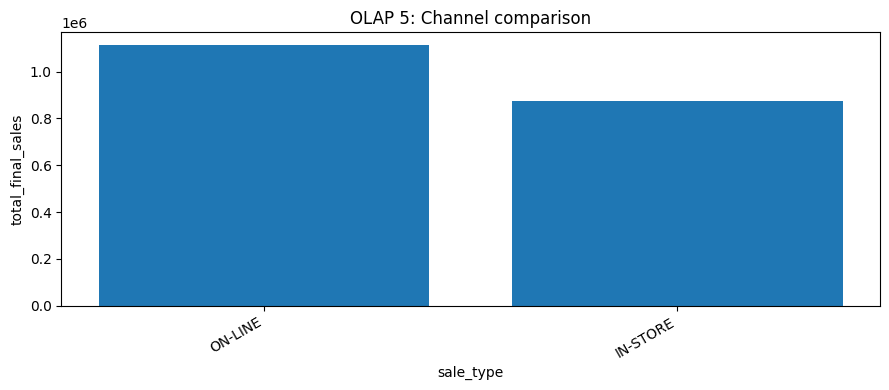

In [36]:
df = con.execute("""
SELECT sale_type, COUNT(*) AS transactions, ROUND(SUM(final_sale_price), 2) AS total_final_sales, ROUND(AVG(final_sale_price), 2) AS avg_transaction_value
FROM gold.fact_sales
GROUP BY sale_type
ORDER BY total_final_sales DESC;
""").df()

plt.figure(figsize=(9,4))
plt.bar(df["sale_type"], df["total_final_sales"])
plt.title("OLAP 5: Channel comparison")
plt.xlabel("sale_type")
plt.ylabel("total_final_sales")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Cell 28 — OLAP 6: Top 10 customers by final sales

### Why
This query demonstrates a common OLAP-style business insight on the Gold layer.


In [37]:
con.execute("""
SELECT c.customer_name, c.customer_email, ROUND(SUM(f.final_sale_price), 2) AS total_final_sales, COUNT(*) AS transactions
FROM gold.fact_sales f
JOIN gold.dim_customer c ON f.customer_key = c.customer_key
GROUP BY c.customer_name, c.customer_email
ORDER BY total_final_sales DESC
LIMIT 10;
""").df()

,customer_name,customer_email,total_final_sales,transactions
0,Megan Carter,megan.carter83@outlook.com,484997.0,300
1,Kevin Johnson,kevin.johnson34@yahoo.com,211197.0,138
2,Rebecca White,rebecca.white18@proton.me,128894.0,79
3,Ryan Jackson,ryan.jackson94@proton.me,97307.0,47
4,Jack Gonzalez,jack.gonzalez6@yahoo.com,78219.5,52
5,Megan Wilson,megan.wilson17@outlook.com,73603.0,45
6,Grace Jackson,grace.jackson80@outlook.com,49310.0,34
7,Jason Perez,jason.perez28@outlook.com,48834.5,36
8,Jeffrey Parker,jeffrey.parker39@proton.me,48380.0,34
9,Bruce Taylor,bruce.taylor94@icloud.com,46463.0,28


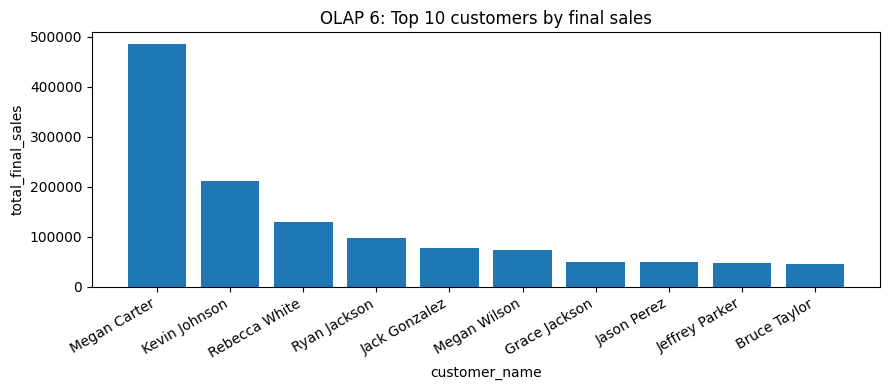

In [38]:
df = con.execute("""
SELECT c.customer_name, c.customer_email, ROUND(SUM(f.final_sale_price), 2) AS total_final_sales, COUNT(*) AS transactions
FROM gold.fact_sales f
JOIN gold.dim_customer c ON f.customer_key = c.customer_key
GROUP BY c.customer_name, c.customer_email
ORDER BY total_final_sales DESC
LIMIT 10;
""").df()

plt.figure(figsize=(9,4))
plt.bar(df["customer_name"], df["total_final_sales"])
plt.title("OLAP 6: Top 10 customers by final sales")
plt.xlabel("customer_name")
plt.ylabel("total_final_sales")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Cell 30 — OLAP 7: Average discount by product

### Why
This query demonstrates a common OLAP-style business insight on the Gold layer.


In [39]:
con.execute("""
SELECT p.product, ROUND(AVG(f.discount), 2) AS avg_discount, ROUND(SUM(f.discount), 2) AS total_discount_given
FROM gold.fact_sales f
JOIN gold.dim_product p ON f.product_key = p.product_key
GROUP BY p.product
ORDER BY avg_discount DESC;
""").df()

,product,avg_discount,total_discount_given
0,EBIKE,145.89,19404.0
1,COMPUTER,124.87,32592.0
2,IPHONE,87.00,30624.0
3,TV,61.43,13023.0
4,IPAD,55.73,8750.0
5,WATCH,39.21,5607.5


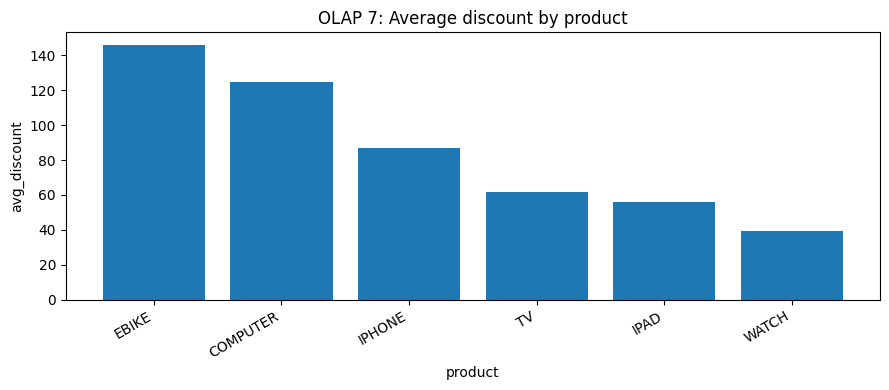

In [40]:
df = con.execute("""
SELECT p.product, ROUND(AVG(f.discount), 2) AS avg_discount, ROUND(SUM(f.discount), 2) AS total_discount_given
FROM gold.fact_sales f
JOIN gold.dim_product p ON f.product_key = p.product_key
GROUP BY p.product
ORDER BY avg_discount DESC;
""").df()

plt.figure(figsize=(9,4))
plt.bar(df["product"], df["avg_discount"])
plt.title("OLAP 7: Average discount by product")
plt.xlabel("product")
plt.ylabel("avg_discount")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Cell 32 — OLAP 8: Product by country matrix

### Why
This query demonstrates a common OLAP-style business insight on the Gold layer.


In [41]:
con.execute("""
SELECT c.customer_country, p.product, ROUND(SUM(f.final_sale_price), 2) AS total_final_sales
FROM gold.fact_sales f
JOIN gold.dim_customer c ON f.customer_key = c.customer_key
JOIN gold.dim_product p ON f.product_key = p.product_key
GROUP BY c.customer_country, p.product
ORDER BY c.customer_country, total_final_sales DESC;
""").df()

,customer_country,product,total_final_sales
0,CANADA,COMPUTER,61012.0
1,CANADA,IPHONE,55132.0
2,CANADA,EBIKE,54538.0
3,CANADA,TV,25650.0
4,CANADA,IPAD,11291.0
5,CANADA,WATCH,6557.5
6,CHINA,IPHONE,14355.0
7,CHINA,COMPUTER,13300.0
8,CHINA,TV,9459.0
9,CHINA,IPAD,7357.0


## Cell 33 — OLAP 9: Quarterly sales rollup

### Why
This query demonstrates a common OLAP-style business insight on the Gold layer.


In [42]:
con.execute("""
SELECT d.year_num, d.quarter_num, ROUND(SUM(f.final_sale_price), 2) AS total_final_sales
FROM gold.fact_sales f
JOIN gold.dim_date d ON f.date_key = d.date_key
GROUP BY d.year_num, d.quarter_num
ORDER BY d.year_num, d.quarter_num;
""").df()

,year_num,quarter_num,total_final_sales
0,2025,1,258866.0
1,2025,2,331718.5
2,2025,3,450127.0
3,2025,4,944538.0


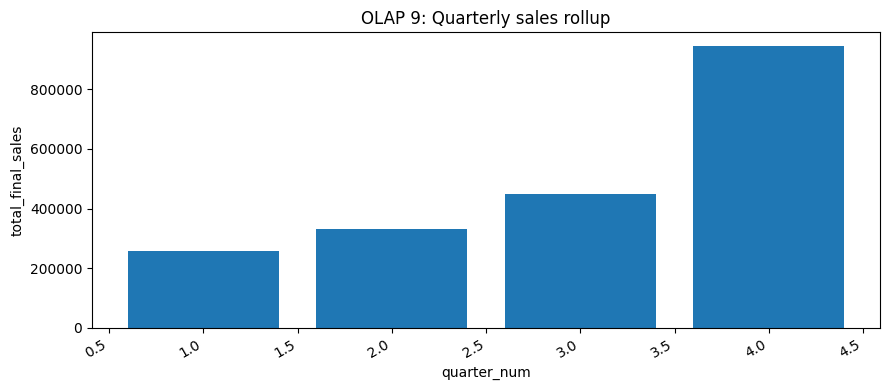

In [43]:
df = con.execute("""
SELECT d.year_num, d.quarter_num, ROUND(SUM(f.final_sale_price), 2) AS total_final_sales
FROM gold.fact_sales f
JOIN gold.dim_date d ON f.date_key = d.date_key
GROUP BY d.year_num, d.quarter_num
ORDER BY d.year_num, d.quarter_num;
""").df()

plt.figure(figsize=(9,4))
plt.bar(df["quarter_num"], df["total_final_sales"])
plt.title("OLAP 9: Quarterly sales rollup")
plt.xlabel("quarter_num")
plt.ylabel("total_final_sales")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Cell 35 — OLAP 10: Month × channel analysis

### Why
This query demonstrates a common OLAP-style business insight on the Gold layer.


In [44]:
con.execute("""
SELECT d.year_month, f.sale_type, ROUND(SUM(f.final_sale_price), 2) AS total_final_sales
FROM gold.fact_sales f
JOIN gold.dim_date d ON f.date_key = d.date_key
GROUP BY d.year_month, f.sale_type
ORDER BY d.year_month, f.sale_type;
""").df()

,year_month,sale_type,total_final_sales
0,2025-01,IN-STORE,25977.0
1,2025-01,ON-LINE,42389.0
2,2025-02,IN-STORE,39048.0
3,2025-02,ON-LINE,46688.0
4,2025-03,IN-STORE,51587.0
5,2025-03,ON-LINE,53177.0
6,2025-04,IN-STORE,46668.5
7,2025-04,ON-LINE,65361.0
8,2025-05,IN-STORE,46304.0
9,2025-05,ON-LINE,55163.5


---
## Show schemas and tables

In [45]:
df = con.execute("""
SELECT 
    table_schema,
    table_name
FROM information_schema.tables
WHERE table_schema IN ('raw','bronze','silver','gold')
ORDER BY table_schema, table_name;
""").df()

# Pretty display grouped by schema
for schema, group in df.groupby("table_schema"):
    print(f"\n📦 Schema: {schema.upper()}")
    print("-" * 40)
    print(group["table_name"].to_string(index=False))
    


📦 Schema: BRONZE
----------------------------------------
sales_raw

📦 Schema: GOLD
----------------------------------------
dim_customer
    dim_date
 dim_product
   dim_store
  fact_sales

📦 Schema: RAW
----------------------------------------
sales_file

📦 Schema: SILVER
----------------------------------------
    cancelled_transactions
          rejected_records
               sales_clean
              step01_dedup
       step02_standardized
     step03_discount_fixed
        step04_date_parsed
step05_valid_non_cancelled


In [47]:
## Show schemas and tables

con.execute("""

SELECT 
    table_schema AS schema,
    table_name AS table
FROM information_schema.tables
WHERE table_schema IN ('raw','bronze','silver','gold')
ORDER BY table_schema, table_name;
""").df()

,schema,table
0,bronze,sales_raw
1,gold,dim_customer
2,gold,dim_date
3,gold,dim_product
4,gold,dim_store
5,gold,fact_sales
6,raw,sales_file
7,silver,cancelled_transactions
8,silver,rejected_records
9,silver,sales_clean


## Final Notes

This revised notebook now shows **exactly when and how** each business rule is implemented:

- **Rule 7** in `silver.step01_dedup`
- **Rule 4** in `silver.step03_discount_fixed`
- **Rules 5 and 6** in `silver.step04_date_parsed`
- **Rules 2, 3, and 6** in `silver.rejected_records`
- **Rule 1** in `silver.cancelled_transactions`
- **Rule 8** in `silver.sales_clean`

This makes the pipeline much easier for students to follow.